Cells: L1=203, L2=982, L3=1758, total=2943


C:\Users\arind\AppData\Local\Temp\ipykernel_11816\1678004155.py:212: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  torch.tensor(G, dtype=torch.float32, device=device),



=== TRAINING ===
epoch 001 | loss=20.33012 | RMSE_model=3.0864 | RMSE_data=0.2692
epoch 002 | loss=11.92534 | RMSE_model=2.3142 | RMSE_data=0.1387
epoch 003 | loss=9.85004 | RMSE_model=1.9974 | RMSE_data=0.1335
epoch 004 | loss=9.38028 | RMSE_model=1.9642 | RMSE_data=0.1355
epoch 005 | loss=8.98172 | RMSE_model=1.9582 | RMSE_data=0.1059
epoch 006 | loss=8.88080 | RMSE_model=1.9369 | RMSE_data=0.1255
epoch 007 | loss=8.66089 | RMSE_model=1.8852 | RMSE_data=0.1237
epoch 008 | loss=8.69235 | RMSE_model=2.1683 | RMSE_data=0.1200
epoch 009 | loss=8.61156 | RMSE_model=1.8897 | RMSE_data=0.1056
epoch 010 | loss=8.43085 | RMSE_model=1.7275 | RMSE_data=0.1069
epoch 011 | loss=8.36933 | RMSE_model=2.2226 | RMSE_data=0.1079
epoch 012 | loss=8.39934 | RMSE_model=1.7265 | RMSE_data=0.1123
epoch 013 | loss=8.27525 | RMSE_model=1.7007 | RMSE_data=0.1090
epoch 014 | loss=8.35891 | RMSE_model=1.7721 | RMSE_data=0.1159
epoch 015 | loss=8.30807 | RMSE_model=1.9109 | RMSE_data=0.1102
epoch 016 | loss=8.1

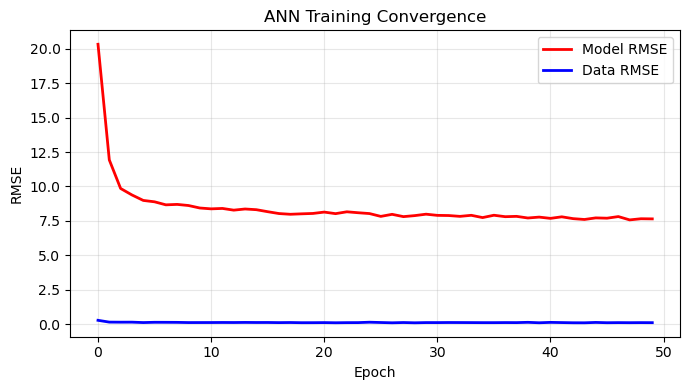

Iter 0001 | RMS=3.87945
Iter 0002 | RMS=3.55709
Iter 0003 | RMS=3.28112
Iter 0004 | RMS=3.03969
Iter 0005 | RMS=2.82686
Iter 0006 | RMS=2.63780
Iter 0007 | RMS=2.46891
Iter 0008 | RMS=2.31728
Iter 0009 | RMS=2.18060
Iter 0010 | RMS=2.05760
Iter 0011 | RMS=1.94624
Iter 0012 | RMS=1.84508
Iter 0013 | RMS=1.75305
Iter 0014 | RMS=1.67251
Iter 0015 | RMS=1.60233
Iter 0016 | RMS=1.53951
Iter 0017 | RMS=1.48344
Iter 0018 | RMS=1.43141
Iter 0019 | RMS=1.38488
Iter 0020 | RMS=1.34479
Iter 0021 | RMS=1.31074
Iter 0022 | RMS=1.27939
Iter 0023 | RMS=1.25168
Iter 0024 | RMS=1.22649
Iter 0025 | RMS=1.20319
Iter 0026 | RMS=1.18144
Iter 0027 | RMS=1.16098
Iter 0028 | RMS=1.14140
Iter 0029 | RMS=1.12300
Iter 0030 | RMS=1.10728
Iter 0031 | RMS=1.09321
Iter 0032 | RMS=1.07991
Iter 0033 | RMS=1.06812
Iter 0034 | RMS=1.05679
Iter 0035 | RMS=1.04605
Iter 0036 | RMS=1.03631
Iter 0037 | RMS=1.02710
Iter 0038 | RMS=1.01868
Iter 0039 | RMS=1.01059
Iter 0040 | RMS=1.00283
Iter 0041 | RMS=0.99525
Iter 0042 | RMS=

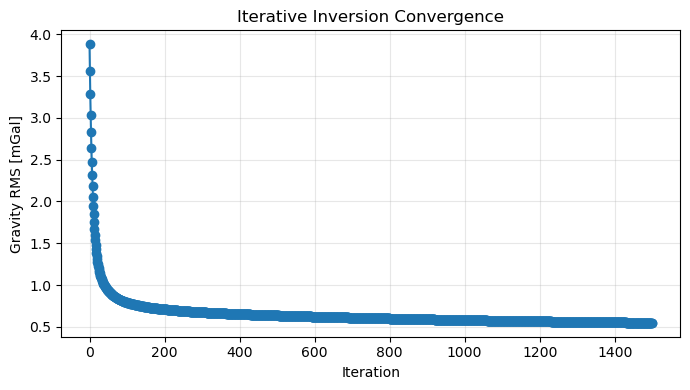

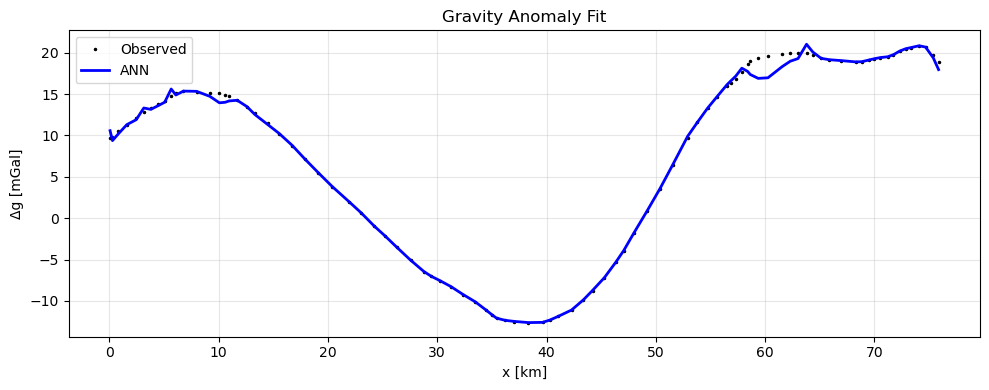

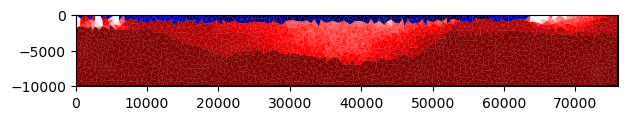

<Figure size 640x480 with 0 Axes>

In [1]:


#!/usr/bin/env python3
# ============================================================
# Physics-informed ANN gravity inversion + iterative refinement
# EXACT seismic horizons preserved
# Full diagnostics saved:
#   - Training RMSE vs epoch
#   - Iterative inversion RMS
#   - Gravity data fit
#   - Final inverted density model
# ============================================================

import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics.gravimetry import GravityModelling2D

# ============================================================
# PARAMETERS
# ============================================================
class Args: pass
args = Args()

args.out_dir      = "MTP_Gravity_ANN"
args.seed         = 42

args.xmax         = 76000.0
args.ymax         = 10000.0
args.cell_area    = 5e5

args.rho1_min     = -500.0
args.rho1_max     = -400.0
args.rho2_min     = -200.0
args.rho2_max     =  50.0
args.rho3_fixed   =  110.0

args.n_samples      = 3000
args.noise_std_mgal = 0.05

args.epochs        = 50
args.batch_size    = 64
args.lr            = 1e-3
args.weight_decay  = 1e-6
args.hidden_width  = 512
args.hidden_layers = 4
args.dropout       = 0.05

args.lambda_phys   = 2.0
args.lambda_smooth = 1e-4
args.lambda_mag    = 1e-7

args.refine_iters  = 1500
args.lambda_refine = 1e-2

args.obs_csv       = "gravity_data.csv"
args.obs_x_unit    = "km"
args.g_unit_label  = "mGal"

# ============================================================
# SETUP
# ============================================================
os.makedirs(args.out_dir, exist_ok=True)
fig_dir = os.path.join(args.out_dir, "figures")
res_dir = os.path.join(args.out_dir, "results")
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(res_dir, exist_ok=True)

torch.manual_seed(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# MESH
# ============================================================
rect = mt.createPolygon(
    [[0,0],[args.xmax,0],[args.xmax,-args.ymax],[0,-args.ymax]],
    isClosed=True
)
mesh = mt.createMesh(rect, quality=34, area=args.cell_area)
M = mesh.cellCount()

centers = np.array([[c.center().x(), -c.center().y()] for c in mesh.cells()])
cx = centers[:,0]
cz_neg = -centers[:,1]

# ============================================================
# SEISMIC HORIZONS (EXACT)
# ============================================================
def _interp_fun(pts):
    pts = np.array(pts, float)
    xs, zs = pts[:,0], pts[:,1]
    srt = np.argsort(xs)
    return lambda xq: np.interp(xq, xs[srt], zs[srt])

scale_x = args.xmax / 76.0
scale_z = args.ymax / 10.0

h1_pts = [
    [0, -0.25*scale_z],[6*scale_x, -0.25*scale_z],[10*scale_x, -1.05*scale_z],
    [50*scale_x, -1.05*scale_z],[53*scale_x, -0.75*scale_z],[60*scale_x, -0.73*scale_z],
    [63*scale_x, -0.62*scale_z],[65*scale_x, 0],[70*scale_x, 0]
]

h2_pts = [
    [0, -1.8*scale_z],[5*scale_x, -1.8*scale_z],[8.5*scale_x, -2.3*scale_z],
    [10.8*scale_x, -2.1*scale_z],[20*scale_x, -5.75*scale_z],[27.5*scale_x, -5.0*scale_z],
    [34*scale_x, -6.0*scale_z],[40*scale_x, -6.8*scale_z],[48*scale_x, -5.6*scale_z],
    [52*scale_x, -2.5*scale_z],[64*scale_x, -2.5*scale_z],[70*scale_x, -2.7*scale_z]
]

z1 = _interp_fun(h1_pts)(cx)
z2 = _interp_fun(h2_pts)(cx)

mask1 = (cz_neg <= 0) & (cz_neg >= z1)
mask2 = (cz_neg < z1) & (cz_neg >= z2)
mask3 = cz_neg < z2

idx1 = np.where(mask1)[0]
idx2 = np.where(mask2)[0]
idx3 = np.where(mask3)[0]
idx_free = np.concatenate([idx1, idx2])

M1, M2, M3 = len(idx1), len(idx2), len(idx3)
print(f"Cells: L1={M1}, L2={M2}, L3={M3}, total={M}")

# ============================================================
# OBSERVED DATA
# ============================================================
def read_x_and_g(csv):
    df = pd.read_csv(csv, sep=None, engine="python")
    x = df.iloc[:,0].values
    g = df.iloc[:,1].values
    if args.obs_x_unit == "km":
        x *= 1000
    return x, g

x_stations, g_obs = read_x_and_g(args.obs_csv)

# ============================================================
# FORWARD OPERATOR
# ============================================================
def build_A(x):
    pts = np.c_[x, np.zeros_like(x)]
    fop = GravityModelling2D(mesh=mesh, points=pts)
    A = np.zeros((len(x), M))
    unit = np.zeros(M)
    for j in range(M):
        unit[:] = 0
        unit[j] = 1
        A[:,j] = fop.response(unit)
    return A

A_np = build_A(x_stations)
A_torch = torch.tensor(A_np, dtype=torch.float32, device=device)

# ============================================================
# ASSEMBLY
# ============================================================
def assemble_rho(r_free):
    rho = torch.zeros(r_free.shape[0], M, device=device)
    rho[:, idx1] = r_free[:, :M1]
    rho[:, idx2] = r_free[:, M1:]
    rho[:, idx3] = args.rho3_fixed
    return rho

# ============================================================
# SMOOTHNESS
# ============================================================
x_order = np.argsort(cx)
nbr_i = torch.tensor(x_order[:-1], device=device)
nbr_j = torch.tensor(x_order[1:], device=device)

def smoothness_loss(rho):
    return ((rho[:,nbr_i] - rho[:,nbr_j])**2).mean()

# ============================================================
# SYNTHETIC DATA GENERATION
# ============================================================
def smooth_x(v, x, L=6000):
    w = np.exp(-0.5*((x[:,None]-x[None,:])/L)**2)
    w /= w.sum(axis=1, keepdims=True)
    return w @ v

def random_model():
    rho = np.full(M, args.rho3_fixed)
    rho[idx1] = smooth_x(
        np.random.uniform(args.rho1_min, args.rho1_max, M1),
        cx[idx1]
    )
    rho[idx2] = smooth_x(
        np.random.uniform(args.rho2_min, args.rho2_max, M2),
        cx[idx2]
    )
    return rho

def sample_batch(n):
    R, G = [], []
    for _ in range(n):
        rho = random_model()
        g = A_np @ rho + np.random.normal(0, args.noise_std_mgal, len(x_stations))
        R.append(rho[idx_free])
        G.append(g)
    return (
        torch.tensor(G, dtype=torch.float32, device=device),
        torch.tensor(R, dtype=torch.float32, device=device)
    )

# ============================================================
# ANN
# ============================================================
class InvNet(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        last = len(x_stations)
        for _ in range(args.hidden_layers):
            layers += [
                nn.Linear(last, args.hidden_width),
                nn.ReLU(),
                nn.Dropout(args.dropout)
            ]
            last = args.hidden_width
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(last, len(idx_free))

    def forward(self, g):
        raw = self.head(self.body(g))
        r1 = args.rho1_min + (args.rho1_max - args.rho1_min) * torch.sigmoid(raw[:,:M1])
        r2 = args.rho2_min + (args.rho2_max - args.rho2_min) * torch.sigmoid(raw[:,M1:])
        return torch.cat([r1, r2], dim=1)

net = InvNet().to(device)
opt = torch.optim.AdamW(net.parameters(), lr=args.lr, weight_decay=args.weight_decay)

# ============================================================
# NORMALIZATION
# ============================================================
with torch.no_grad():
    Gs, _ = sample_batch(512)
g_mu = Gs.mean(0)
g_std = Gs.std(0).clamp_min(1e-6)
def norm_g(g): return (g - g_mu) / g_std

# ============================================================
# TRAINING
# ============================================================
train_loss_hist = []
rmse_model_hist = []
rmse_data_hist  = []

steps = max(1, args.n_samples // args.batch_size // 4)
print("\n=== TRAINING ===")

for ep in range(1, args.epochs + 1):
    net.train()
    total = 0.0

    for _ in range(steps):
        g, r = sample_batch(args.batch_size)
        rp = net(norm_g(g))
        rho = assemble_rho(rp)
        gp = torch.matmul(rho, A_torch.T)

        loss = (
            F.mse_loss(rp, r)
            + args.lambda_phys * F.mse_loss(gp, g)
            + args.lambda_smooth * smoothness_loss(rho)
            + args.lambda_mag * (rp**2).mean()
        )

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()

    net.eval()
    with torch.no_grad():
        g, r = sample_batch(8)
        rp = net(norm_g(g))
        rho = assemble_rho(rp)
        gp = torch.matmul(rho, A_torch.T)
        rm = F.mse_loss(rp, r).sqrt().item()
        rd = F.mse_loss(gp, g).sqrt().item()

    train_loss_hist.append(total / steps)
    rmse_model_hist.append(rm)
    rmse_data_hist.append(rd)

    print(f"epoch {ep:03d} | loss={total/steps:.5f} | RMSE_model={rm:.4f} | RMSE_data={rd:.4f}")

# ============================================================
# SAVE TRAINING DIAGNOSTICS
# ============================================================
np.savez(
    os.path.join(res_dir, "training_diagnostics.npz"),
    train_loss=train_loss_hist,
)

plt.figure(figsize=(7,4))
plt.plot(train_loss_hist, 'r-', lw=2, label="Model RMSE")
plt.plot(rmse_data_hist,  'b-', lw=2, label="Data RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("ANN Training Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "training_rmse_vs_epoch.png"), dpi=300)
plt.show()

# ============================================================
# ANN INVERSION
# ============================================================
net.eval()
with torch.no_grad():
    r_free = net(norm_g(torch.tensor(g_obs, dtype=torch.float32, device=device)[None,:]))
    rho_ann = assemble_rho(r_free)[0].cpu().numpy()

np.save(os.path.join(res_dir, "rho_ann.npy"), rho_ann)

# ============================================================
# ITERATIVE REFINEMENT
# ============================================================
def refine(rho, g, A, lam, niter):
    Af = A[:, idx_free]
    I = np.eye(len(idx_free))
    rms = []

    for k in range(niter):
        r = g - A @ rho
        rms.append(np.sqrt(np.mean(r**2)))
        d = np.linalg.solve(Af.T @ Af + lam * I, Af.T @ r)
        rho[idx_free] += d
        rho[idx1] = np.clip(rho[idx1], args.rho1_min, args.rho1_max)
        rho[idx2] = np.clip(rho[idx2], args.rho2_min, args.rho2_max)
        rho[idx3] = args.rho3_fixed
        print(f"Iter {k+1:04d} | RMS={rms[-1]:.5f}")

    return rho, np.array(rms)

rho_final, rms_iter = refine(
    rho_ann.copy(),
    g_obs,
    A_np,
    args.lambda_refine,
    args.refine_iters
)

np.save(os.path.join(res_dir, "rho_final.npy"), rho_final)
np.save(os.path.join(res_dir, "iterative_rms.npy"), rms_iter)

# ============================================================
# ITERATIVE RMS PLOT
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(rms_iter, 'o-', lw=1.5)
plt.xlabel("Iteration")
plt.ylabel("Gravity RMS [mGal]")
plt.title("Iterative Inversion Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "iterative_rms_vs_iteration.png"), dpi=300)
plt.show()

# ============================================================
# FINAL GRAVITY FIT
# ============================================================
g_final = A_np @ rho_final

np.savez(
    os.path.join(res_dir, "gravity_fit.npz"),
    x_km=x_stations/1000,
    g_obs=g_obs,
    g_final=g_final
)

plt.figure(figsize=(10,4))
plt.plot(x_stations/1000, g_obs, "k.", ms=3, label="Observed")
plt.plot(x_stations/1000, g_final, "b-", lw=2, label="ANN")
plt.xlabel("x [km]")
plt.ylabel(f"Δg [{args.g_unit_label}]")
plt.title("Gravity Anomaly Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "gravity_data_fit.png"), dpi=300)
plt.show()

# ============================================================
# FINAL DENSITY MODEL
# ============================================================
vmax = max(150, np.percentile(np.abs(rho_final), 98))

fig, ax = plt.subplots(figsize=(7,4))
pg.show(
    mesh,
    rho_final,
    cMap="seismic",
    vmin=-vmax,
    vmax=vmax,
    label="Density contrast (kg/m³)",
    ax=ax
)
ax.set_title("Inverted Density Model")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "inverted_density_model.png"), dpi=800)
plt.show()


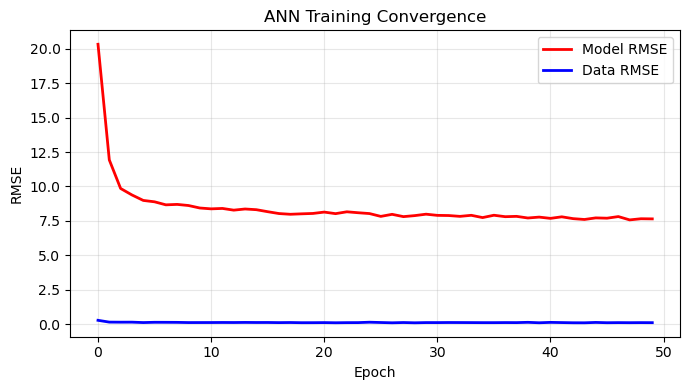

Iter 0001 | RMS=3.87945
Iter 0002 | RMS=3.55709
Iter 0003 | RMS=3.28112
Iter 0004 | RMS=3.03969
Iter 0005 | RMS=2.82686
Iter 0006 | RMS=2.63780
Iter 0007 | RMS=2.46891
Iter 0008 | RMS=2.31728
Iter 0009 | RMS=2.18060
Iter 0010 | RMS=2.05760
Iter 0011 | RMS=1.94624
Iter 0012 | RMS=1.84508
Iter 0013 | RMS=1.75305
Iter 0014 | RMS=1.67251
Iter 0015 | RMS=1.60233
Iter 0016 | RMS=1.53951
Iter 0017 | RMS=1.48344
Iter 0018 | RMS=1.43141
Iter 0019 | RMS=1.38488
Iter 0020 | RMS=1.34479
Iter 0021 | RMS=1.31074
Iter 0022 | RMS=1.27939
Iter 0023 | RMS=1.25168
Iter 0024 | RMS=1.22649
Iter 0025 | RMS=1.20319
Iter 0026 | RMS=1.18144
Iter 0027 | RMS=1.16098
Iter 0028 | RMS=1.14140
Iter 0029 | RMS=1.12300
Iter 0030 | RMS=1.10728
Iter 0031 | RMS=1.09321
Iter 0032 | RMS=1.07991
Iter 0033 | RMS=1.06812
Iter 0034 | RMS=1.05679
Iter 0035 | RMS=1.04605
Iter 0036 | RMS=1.03631
Iter 0037 | RMS=1.02710
Iter 0038 | RMS=1.01868
Iter 0039 | RMS=1.01059
Iter 0040 | RMS=1.00283
Iter 0041 | RMS=0.99525
Iter 0042 | RMS=

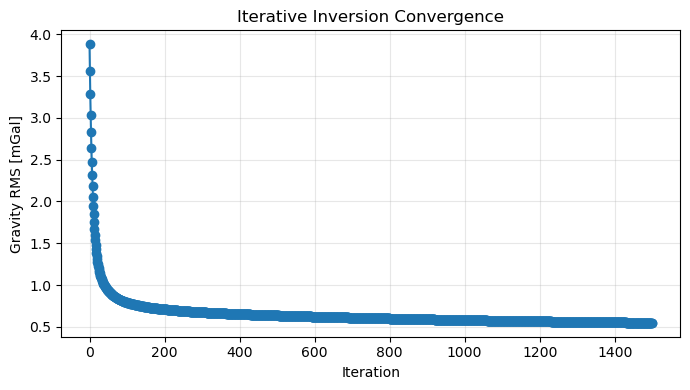

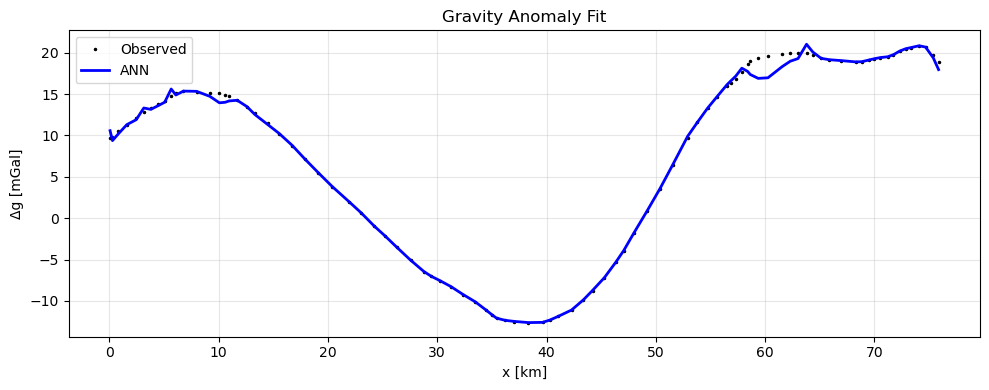

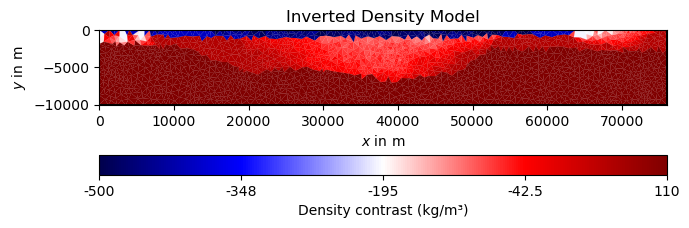

In [2]:
# ============================================================
# SAVE TRAINING DIAGNOSTICS
# ============================================================
np.savez(
    os.path.join(res_dir, "training_diagnostics.npz"),
    train_loss=train_loss_hist,
)

plt.figure(figsize=(7,4))
plt.plot(train_loss_hist, 'r-', lw=2, label="Model RMSE")
plt.plot(rmse_data_hist,  'b-', lw=2, label="Data RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("ANN Training Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "training_rmse_vs_epoch.png"), dpi=300)
plt.show()

# ============================================================
# ANN INVERSION
# ============================================================
net.eval()
with torch.no_grad():
    r_free = net(norm_g(torch.tensor(g_obs, dtype=torch.float32, device=device)[None,:]))
    rho_ann = assemble_rho(r_free)[0].cpu().numpy()

np.save(os.path.join(res_dir, "rho_ann.npy"), rho_ann)

# ============================================================
# ITERATIVE REFINEMENT
# ============================================================
def refine(rho, g, A, lam, niter):
    Af = A[:, idx_free]
    I = np.eye(len(idx_free))
    rms = []

    for k in range(niter):
        r = g - A @ rho
        rms.append(np.sqrt(np.mean(r**2)))
        d = np.linalg.solve(Af.T @ Af + lam * I, Af.T @ r)
        rho[idx_free] += d
        rho[idx1] = np.clip(rho[idx1], args.rho1_min, args.rho1_max)
        rho[idx2] = np.clip(rho[idx2], args.rho2_min, args.rho2_max)
        rho[idx3] = args.rho3_fixed
        print(f"Iter {k+1:04d} | RMS={rms[-1]:.5f}")

    return rho, np.array(rms)

rho_final, rms_iter = refine(
    rho_ann.copy(),
    g_obs,
    A_np,
    args.lambda_refine,
    args.refine_iters
)

np.save(os.path.join(res_dir, "rho_final.npy"), rho_final)
np.save(os.path.join(res_dir, "iterative_rms.npy"), rms_iter)

# ============================================================
# ITERATIVE RMS PLOT
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(rms_iter, 'o-', lw=1.5)
plt.xlabel("Iteration")
plt.ylabel("Gravity RMS [mGal]")
plt.title("Iterative Inversion Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "iterative_rms_vs_iteration.png"), dpi=300)
plt.show()

# ============================================================
# FINAL GRAVITY FIT
# ============================================================
g_final = A_np @ rho_final

np.savez(
    os.path.join(res_dir, "gravity_fit.npz"),
    x_km=x_stations/1000,
    g_obs=g_obs,
    g_final=g_final
)

plt.figure(figsize=(10,4))
plt.plot(x_stations/1000, g_obs, "k.", ms=3, label="Observed")
plt.plot(x_stations/1000, g_final, "b-", lw=2, label="ANN")
plt.xlabel("x [km]")
plt.ylabel(f"Δg [{args.g_unit_label}]")
plt.title("Gravity Anomaly Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "gravity_data_fit.png"), dpi=300)
plt.show()

# ============================================================
# FINAL DENSITY MODEL
# ============================================================
vmax = max(150, np.percentile(np.abs(rho_final), 98))

fig, ax = plt.subplots(figsize=(7,4))
pg.show(
    mesh,
    rho_final,
    cMap="seismic",
    vmin=-vmax,
    vmax=vmax,
    label="Density contrast (kg/m³)",
    ax=ax
)
ax.set_title("Inverted Density Model")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "inverted_density_model.png"), dpi=800)
plt.show()


In [3]:
# ============================================================
# MONTE-CARLO UNCERTAINTY QUANTIFICATION
# ============================================================

N_mc = 100            # 50–100 is enough for thesis
noise_std = args.noise_std_mgal

print(f"\n=== MONTE-CARLO UQ ({N_mc} realizations) ===")

rho_mc = np.zeros((N_mc, M))
rms_mc = np.zeros(N_mc)



=== MONTE-CARLO UQ (100 realizations) ===


In [4]:
for k in range(N_mc):
    print(f"MC realization {k+1:03d}/{N_mc}")

    # ---- Perturb observed gravity ----
    gk = g_obs + np.random.normal(0, noise_std, len(g_obs))

    # ---- ANN inversion ----
    with torch.no_grad():
        gk_t = torch.tensor(gk, dtype=torch.float32, device=device)[None, :]
        r_free = net(norm_g(gk_t))
        rho0 = assemble_rho(r_free)[0].cpu().numpy()

    # ---- Iterative refinement (shorter run is enough) ----
    rho_k, rms_k = refine(
        rho0,
        gk,
        A_np,
        args.lambda_refine,
        niter=300        # << shorter than main inversion
    )

    rho_mc[k] = rho_k
    rms_mc[k] = rms_k[-1]


MC realization 001/100
Iter 0001 | RMS=3.87653
Iter 0002 | RMS=3.55457
Iter 0003 | RMS=3.27895
Iter 0004 | RMS=3.03781
Iter 0005 | RMS=2.82521
Iter 0006 | RMS=2.63635
Iter 0007 | RMS=2.46763
Iter 0008 | RMS=2.31615
Iter 0009 | RMS=2.17964
Iter 0010 | RMS=2.05679
Iter 0011 | RMS=1.94564
Iter 0012 | RMS=1.84457
Iter 0013 | RMS=1.75242
Iter 0014 | RMS=1.67159
Iter 0015 | RMS=1.60125
Iter 0016 | RMS=1.53819
Iter 0017 | RMS=1.48219
Iter 0018 | RMS=1.43005
Iter 0019 | RMS=1.38366
Iter 0020 | RMS=1.34273
Iter 0021 | RMS=1.30843
Iter 0022 | RMS=1.27690
Iter 0023 | RMS=1.24900
Iter 0024 | RMS=1.22357
Iter 0025 | RMS=1.19999
Iter 0026 | RMS=1.17827
Iter 0027 | RMS=1.15781
Iter 0028 | RMS=1.13828
Iter 0029 | RMS=1.12001
Iter 0030 | RMS=1.10407
Iter 0031 | RMS=1.08994
Iter 0032 | RMS=1.07663
Iter 0033 | RMS=1.06445
Iter 0034 | RMS=1.05318
Iter 0035 | RMS=1.04237
Iter 0036 | RMS=1.03228
Iter 0037 | RMS=1.02301
Iter 0038 | RMS=1.01452
Iter 0039 | RMS=1.00640
Iter 0040 | RMS=0.99859
Iter 0041 | RMS=0

In [5]:
rho_mean = rho_mc.mean(axis=0)
rho_std  = rho_mc.std(axis=0)

np.save(os.path.join(res_dir, "rho_mc.npy"), rho_mc)
np.save(os.path.join(res_dir, "rho_mc_mean.npy"), rho_mean)
np.save(os.path.join(res_dir, "rho_mc_std.npy"), rho_std)
np.save(os.path.join(res_dir, "rho_mc_rms.npy"), rms_mc)


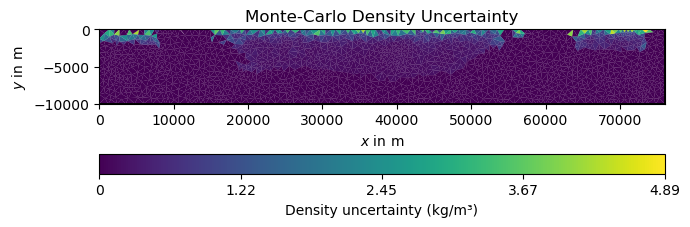

In [6]:
vmax = np.percentile(rho_std[idx_free], 50)

fig, ax = plt.subplots(figsize=(7,4))
pg.show(
    mesh,
    rho_std,
    cMap="viridis",
    vmin=0,
    vmax=4,
    label="Density uncertainty (kg/m³)",
    ax=ax
)
ax.set_title("Monte-Carlo Density Uncertainty")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "density_uncertainty_mc.png"), dpi=600)
plt.show()


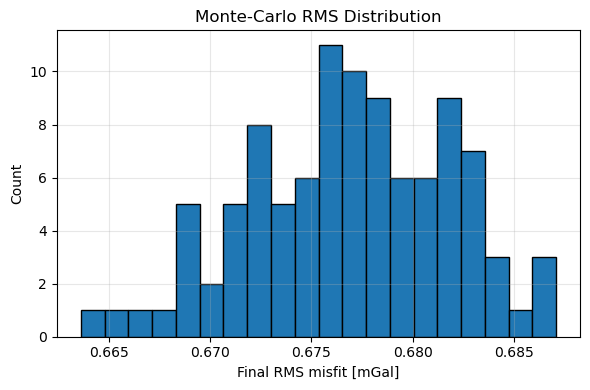

In [7]:
plt.figure(figsize=(6,4))
plt.hist(rms_mc, bins=20, edgecolor='k')
plt.xlabel("Final RMS misfit [mGal]")
plt.ylabel("Count")
plt.title("Monte-Carlo RMS Distribution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "mc_rms_histogram.png"), dpi=600)
plt.show()


In [8]:
# ============================================================
# MODEL PARAMETER UNCERTAINTY (MONTE-CARLO POSTERIOR)
# ============================================================

N_mc = 100                      # 50–100 sufficient
noise_std = args.noise_std_mgal

rho_mc = np.zeros((N_mc, M))
rms_mc = np.zeros(N_mc)

print("\n=== MODEL PARAMETER UNCERTAINTY (MC) ===")

for k in range(N_mc):
    print(f"MC run {k+1:03d}/{N_mc}")

    # ---- perturb observed gravity ----
    gk = g_obs + np.random.normal(0, noise_std, len(g_obs))

    # ---- ANN prediction ----
    with torch.no_grad():
        gk_t = torch.tensor(gk, dtype=torch.float32, device=device)[None, :]
        r_free = net(norm_g(gk_t))
        rho0 = assemble_rho(r_free)[0].cpu().numpy()

    # ---- deterministic refinement ----
    rho_k, rms_k = refine(
        rho0,
        gk,
        A_np,
        args.lambda_refine,
        niter=300      # shorter is fine
    )

    rho_mc[k] = rho_k
    rms_mc[k] = rms_k[-1]



=== MODEL PARAMETER UNCERTAINTY (MC) ===
MC run 001/100
Iter 0001 | RMS=3.85661
Iter 0002 | RMS=3.53623
Iter 0003 | RMS=3.26204
Iter 0004 | RMS=3.02223
Iter 0005 | RMS=2.81088
Iter 0006 | RMS=2.62314
Iter 0007 | RMS=2.45544
Iter 0008 | RMS=2.30488
Iter 0009 | RMS=2.16916
Iter 0010 | RMS=2.04691
Iter 0011 | RMS=1.93622
Iter 0012 | RMS=1.83574
Iter 0013 | RMS=1.74429
Iter 0014 | RMS=1.66479
Iter 0015 | RMS=1.59503
Iter 0016 | RMS=1.53246
Iter 0017 | RMS=1.47672
Iter 0018 | RMS=1.42490
Iter 0019 | RMS=1.37842
Iter 0020 | RMS=1.33861
Iter 0021 | RMS=1.30474
Iter 0022 | RMS=1.27406
Iter 0023 | RMS=1.24669
Iter 0024 | RMS=1.22166
Iter 0025 | RMS=1.19863
Iter 0026 | RMS=1.17697
Iter 0027 | RMS=1.15660
Iter 0028 | RMS=1.13707
Iter 0029 | RMS=1.11860
Iter 0030 | RMS=1.10304
Iter 0031 | RMS=1.08886
Iter 0032 | RMS=1.07586
Iter 0033 | RMS=1.06409
Iter 0034 | RMS=1.05291
Iter 0035 | RMS=1.04233
Iter 0036 | RMS=1.03250
Iter 0037 | RMS=1.02325
Iter 0038 | RMS=1.01495
Iter 0039 | RMS=1.00694
Iter 00

In [36]:
rho_mean = rho_mc.mean(axis=0)
rho_std  = rho_mc.std(axis=0)

np.save("rho_mc.npy", rho_mc)
np.save("rho_mean.npy", rho_mean)
np.save("rho_std.npy", rho_std)
np.save("rho_mc_rms.npy", rms_mc)


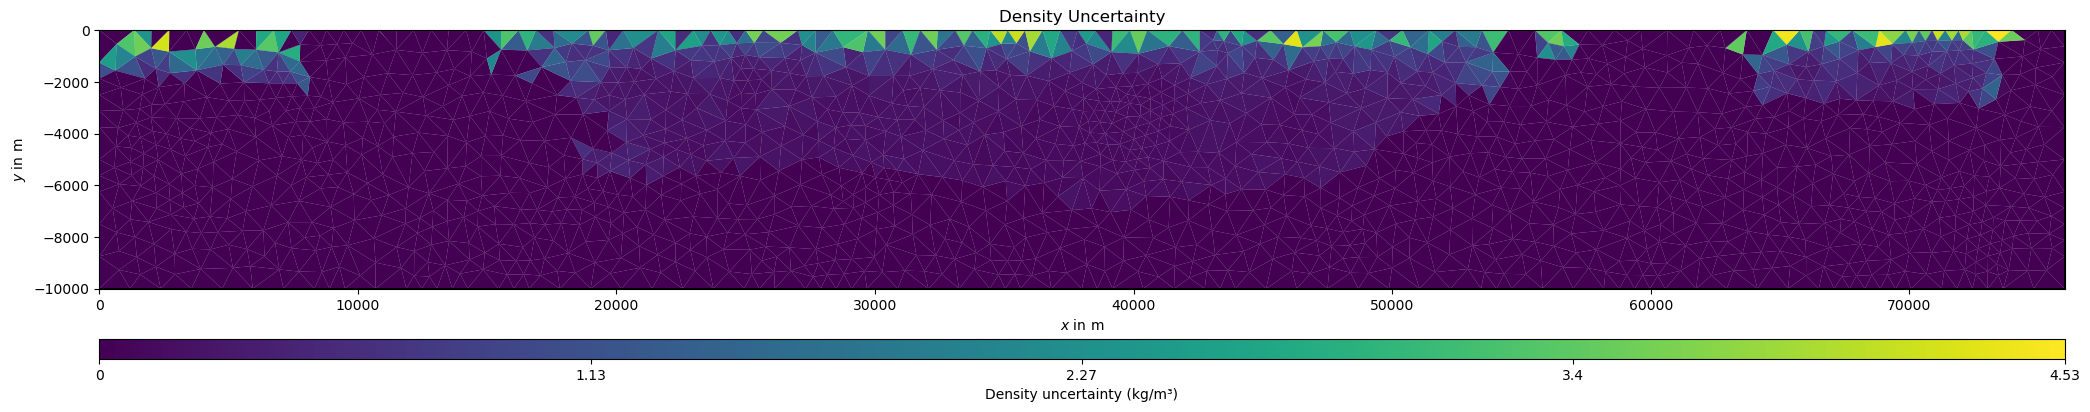

In [37]:

vmax = np.percentile(rho_std[idx_free], 8)

fig, ax = plt.subplots(figsize=(21,5))
pg.show(
    mesh,
    rho_std,
    cMap="viridis",
    vmin=0,
    vmax=1,
    label="Density uncertainty (kg/m³)",
    ax=ax
)
ax.set_title("Density Uncertainty")
plt.tight_layout()
plt.savefig("density_uncertainty_mc.png", dpi=600)
plt.show()


In [11]:

# ============================================================
# SENSITIVITY ANALYSIS (MODEL SENSITIVITY MAP)
# ============================================================

# L2-norm of each column of A (global sensitivity)
sensitivity = np.sqrt(np.sum(A_np**2, axis=0))

# Normalize for visualization
sensitivity_norm = sensitivity / sensitivity.max()

np.save(os.path.join(res_dir, "sensitivity.npy"), sensitivity_norm)


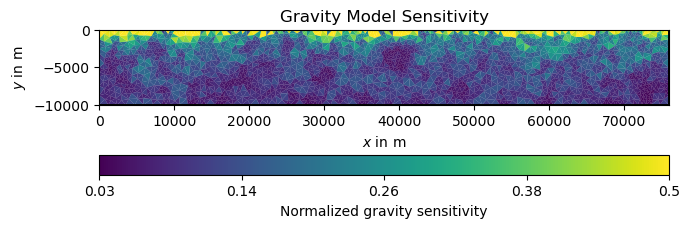

In [38]:
sens_plot = sensitivity_norm.copy()
sens_plot[sens_plot > 0.5] = 0.5  # hard clip

fig, ax = plt.subplots(figsize=(7,4))

pg.show(
    mesh,
    sens_plot,
    cMap="viridis",
    vmin=0.0,
    vmax=0.5,
    label="Normalized gravity sensitivity",
    ax=ax
)

ax.set_title("Gravity Model Sensitivity")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "sensitivity_map.png"), dpi=600)
plt.show()



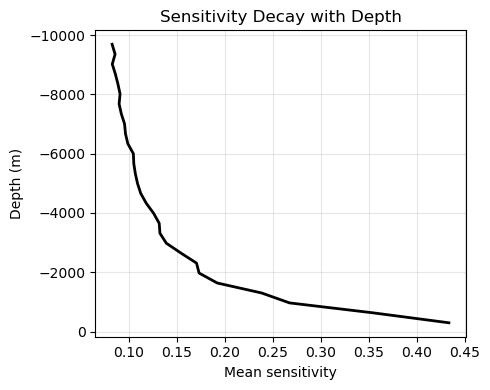

In [19]:
# Bin sensitivity by depth
depth = cz_neg
bins = np.linspace(depth.min(), depth.max(), 30)
sens_depth = []

for i in range(len(bins)-1):
    mask = (depth >= bins[i]) & (depth < bins[i+1])
    sens_depth.append(sensitivity_norm[mask].mean())

plt.figure(figsize=(5,4))
plt.plot(sens_depth, 0.5*(bins[:-1]+bins[1:]), 'k-', lw=2)
plt.gca().invert_yaxis()
plt.xlabel("Mean sensitivity")
plt.ylabel("Depth (m)")
plt.title("Sensitivity Decay with Depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "sensitivity_depthwise.png"), dpi=600)
plt.show()
